# Notebook 3: Reinforcement Learning for EV Fleet Charging
## IEOR E4010 — AI for Operations Research and Financial Engineering
### Columbia University, Spring 2026

---

## Overview

In this notebook you will train a **Proximal Policy Optimization (PPO)** agent to minimize the total cost of charging a 50-vehicle EV taxi fleet in New York City.

The agent operates a **battery energy storage system (BESS)** and **20 chargers** at a depot, deciding every 5 minutes:
1. How fast to charge each of 10 DC fast chargers (powered from the BESS)
2. Whether to turn on each of 10 Level 2 AC slow chargers (powered from the grid)
3. How fast to charge the BESS from the grid

The total cost includes:
- **Electricity cost**: grid draw × real-time NYISO price
- **Demand charge**: monthly peak grid draw × tariff rate
- **Opportunity cost**: revenue lost when vehicles sit idle but charged
- **Deadline penalty**: vehicles that depart below 70% SoC target

### What you will do
1. Understand the `EVChargingEnv` Gymnasium environment
2. Run 3 heuristic baselines and an LP lower bound
3. **Train a baseline PPO agent** (provided)
4. **Design a custom reward function** to improve performance (your main task)
5. **Integrate price forecasts** into the agent's state
6. Export your trained agent to `submission/rl_agent.zip`

### Grading (50% of project score)
Your RL score is based on **mean episode cost** over 50 held-out evaluation episodes. Lower is better. Score is relative to the heuristic baselines.

In [1]:
# ============================================================
# SETUP — Install dependencies and clone repo if on Colab
# ============================================================
import os, sys, shutil

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('EV_Fleet_Project'):
        !git clone https://github.com/x1linwang/EV_Fleet_Project.git
    os.chdir('EV_Fleet_Project')

!pip install -r requirements.txt
print('Setup complete.')

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

DATA_FILES = [
    "nyiso_prices_weather_nyc_2025.csv",
    "nyiso_rt_lbmp_nyc_2025_5min.csv",
    "nyc_fleet_profiles.json",
]

Cloning into 'EV_Fleet_Project'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 19 (delta 1), reused 19 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 2.03 MiB | 9.78 MiB/s, done.
Resolving deltas: 100% (1/1), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.6 MB/s eta 0:00:00
Setup complete.


---
## Section 0: The EVChargingEnv Environment

Read through this carefully — the entire project is built on this environment.

In [2]:
import gymnasium as gym
import numpy as np
import pandas as pd
import json
from scipy.stats import truncnorm


class EVChargingEnv(gym.Env):
    """
    Gymnasium environment for EV fleet charging optimization.

    Episode = 24 hours, 288 timesteps (5-min resolution).

    State (observation) vector dimensions:
      1  : BESS SoC
      30 : 10 fast charger slots × (occupied, vehicle_soc, steps_until_departure)
      30 : 10 slow charger slots × (occupied, vehicle_soc, steps_until_departure)
      1  : queue length
      1  : current price
      1  : fractional hour in episode
      1  : previous grid draw
      +n : optional price forecast steps
    Total base: 65 dims

    Action vector (21 dims, all in [0,1]):
      10 : fast charger rates  (× 150 kW each)
      10 : slow charger on/off (thresholded at 0.5)
      1  : BESS charge rate    (× 500 kW)
    """

    metadata = {"render_modes": []}

    # Physical constants
    VEHICLE_BATTERY_KWH   = 76.0
    FLEET_SIZE            = 50
    N_FAST                = 10
    N_SLOW                = 10
    MAX_FAST_KW           = 150.0
    MAX_SLOW_KW           = 11.0
    BESS_CAPACITY         = 1000.0
    BESS_MAX_DISCHARGE_KW = 1500.0
    BESS_MAX_CHARGE_KW    = 500.0
    BESS_EFF              = 0.92
    DC_EFF                = 0.90
    SLOW_EFF              = 0.93
    GRID_MAX_KW           = 500.0
    TARGET_SOC            = 0.70
    DT                    = 5 / 60   # hours per step
    N_STEPS               = 288      # 24h × 12 steps/h
    DEADLINE_PENALTY      = 50.0     # $ per vehicle per % below target

    # Demand charge tariffs (Con Edison PSC SC-9 General Large, ~2025)
    DEMAND_CHARGE_SUMMER  = 53.60    # $/kW, June–Sept, 8AM–6PM weekdays
    DEMAND_CHARGE_ALL     = 41.24    # $/kW, all other periods

    def __init__(self, price_df_5min, fleet_profiles, seed=None,
                 reward_weights=None, forecast_fn=None, n_forecast_steps=0):
        super().__init__()

        self.price_df        = price_df_5min.reset_index(drop=True)
        self.fleet_profiles  = fleet_profiles
        self.forecast_fn     = forecast_fn
        self.n_forecast_steps = n_forecast_steps

        self.rw = reward_weights or {
            "electricity": 1.0,
            "opportunity": 1.0,
            "deadline":    1.0,
            "peak_demand": 1.0,
        }

        # Observation space
        n_obs = 1 + (self.N_FAST * 3) + (self.N_SLOW * 3) + 1 + 1 + 1 + 1 + n_forecast_steps
        self.observation_space = gym.spaces.Box(
            low=-1.0, high=1.0, shape=(n_obs,), dtype=np.float32
        )

        # Action space: [fast_rates(10), slow_onoff(10), bess_charge_rate(1)]
        self.action_space = gym.spaces.Box(
            low=0.0, high=1.0, shape=(21,), dtype=np.float32
        )

        self.np_random = np.random.default_rng(seed)
        self._episode_days = self._get_unique_days()

    def _get_unique_days(self):
        self.price_df["_date"] = pd.to_datetime(self.price_df["timestamp"]).dt.date
        return self.price_df["_date"].unique().tolist()

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.np_random = np.random.default_rng(seed)

        # Pick a random day
        day_idx = int(self.np_random.integers(0, len(self._episode_days)))
        self._episode_day = self._episode_days[day_idx]

        day_mask = self.price_df["_date"] == self._episode_day
        day_data = self.price_df[day_mask].reset_index(drop=True)
        if len(day_data) < self.N_STEPS:
            pad = self.N_STEPS - len(day_data)
            day_data = pd.concat(
                [day_data] + [day_data.iloc[[-1]]] * pad, ignore_index=True
            )
        self._prices_kwh = day_data["rt_lbmp_kwh"].values[:self.N_STEPS].astype(np.float32)
        self._prices_mwh = day_data["rt_lbmp_mwh"].values[:self.N_STEPS].astype(np.float32)

        ts0 = pd.Timestamp(self._episode_day)
        self._day_of_week = ts0.dayofweek
        self._is_weekend  = self._day_of_week >= 5
        self._month       = ts0.month

        # BESS initial SoC: uniform in [30%, 90%]
        self._bess_soc = float(self.np_random.uniform(0.30, 0.90))

        # Charger slots
        self._fast_slots    = [None] * self.N_FAST
        self._slow_slots    = [None] * self.N_SLOW
        self._vehicle_queue = []

        # Pre-populate depot
        n_initial = int(self.np_random.integers(3, 12))
        for _ in range(n_initial):
            v = self._new_vehicle(step=0)
            placed = False
            for i in range(self.N_SLOW):
                if self._slow_slots[i] is None:
                    self._slow_slots[i] = v
                    placed = True
                    break
            if not placed:
                for i in range(self.N_FAST):
                    if self._fast_slots[i] is None:
                        self._fast_slots[i] = v
                        placed = True
                        break
            if not placed:
                self._vehicle_queue.append(v)

        self._step_idx      = 0
        self._max_grid_draw = 0.0
        self._total_cost    = 0.0
        self._total_opp_cost = 0.0
        self._missed_deadlines = 0
        self._prev_grid_draw = 0.0

        return self._get_obs(), {}

    def _new_vehicle(self, step):
        soc_params = self.fleet_profiles["arrival_soc"]
        a = (soc_params["min"] - soc_params["mean"]) / soc_params["std"]
        b = (soc_params["max"] - soc_params["mean"]) / soc_params["std"]
        seed_int = int(self.np_random.integers(0, 2**30))
        soc = float(
            truncnorm.rvs(a, b, loc=soc_params["mean"], scale=soc_params["std"],
                          random_state=seed_int)
        )
        soc = float(np.clip(soc, soc_params["min"], soc_params["max"]))

        hour = (step // 12) % 24
        demand_key  = "weekend" if self._is_weekend else "weekday"
        demand      = self.fleet_profiles["ride_demand"][demand_key][hour]
        max_demand  = max(self.fleet_profiles["ride_demand"]["weekday"])
        demand_frac = demand / max_demand

        if demand_frac > 0.6:
            depart_steps = int(self.np_random.integers(4, 18))
        else:
            depart_steps = int(self.np_random.integers(24, 96))

        depart_step = min(step + depart_steps, self.N_STEPS - 1)

        return {"soc": soc, "depart_step": depart_step, "arrival_step": step}

    def _process_arrivals(self):
        hour       = (self._step_idx // 12) % 24
        demand_key = "weekend" if self._is_weekend else "weekday"
        lam_hourly = self.fleet_profiles["depot_arrival_rate"][demand_key][hour]
        lam_step   = lam_hourly / 12
        n_arrivals = int(self.np_random.poisson(lam_step))
        for _ in range(n_arrivals):
            v = self._new_vehicle(self._step_idx)
            self._vehicle_queue.append(v)

    def _assign_from_queue(self):
        for i in range(self.N_SLOW):
            if self._slow_slots[i] is None and self._vehicle_queue:
                self._slow_slots[i] = self._vehicle_queue.pop(0)
        for i in range(self.N_FAST):
            if self._fast_slots[i] is None and self._vehicle_queue:
                self._fast_slots[i] = self._vehicle_queue.pop(0)

    def _get_obs(self):
        obs = []

        # BESS SoC
        obs.append(float(self._bess_soc) * 2 - 1)

        # Fast charger slots (10 × 3)
        for slot in self._fast_slots:
            if slot is None:
                obs.extend([0.0, 0.0, 0.0])
            else:
                steps_left = max(0, slot["depart_step"] - self._step_idx)
                obs.extend([
                    1.0,
                    float(slot["soc"]) * 2 - 1,
                    float(min(steps_left / 96, 1.0)) * 2 - 1,
                ])

        # Slow charger slots (10 × 3)
        for slot in self._slow_slots:
            if slot is None:
                obs.extend([0.0, 0.0, 0.0])
            else:
                steps_left = max(0, slot["depart_step"] - self._step_idx)
                obs.extend([
                    1.0,
                    float(slot["soc"]) * 2 - 1,
                    float(min(steps_left / 96, 1.0)) * 2 - 1,
                ])

        # Queue length (normalized)
        obs.append(float(min(len(self._vehicle_queue) / 10, 1.0)) * 2 - 1)

        # Current price (normalize by 0.2 $/kWh)
        price = self._prices_kwh[self._step_idx] if self._step_idx < self.N_STEPS else 0.0
        obs.append(float(np.clip(price / 0.20, -1.0, 1.0)))

        # Fractional position in episode [-1, 1]
        obs.append(float(self._step_idx / self.N_STEPS) * 2 - 1)

        # Previous grid draw
        obs.append(float(np.clip(self._prev_grid_draw / self.GRID_MAX_KW, 0.0, 1.0)) * 2 - 1)

        # Price forecast
        if self.n_forecast_steps > 0:
            if self.forecast_fn is not None:
                fc = self.forecast_fn(self._step_idx, self._prices_kwh)
                fc_vals = np.clip(np.asarray(fc[:self.n_forecast_steps], dtype=np.float32) / 0.20, -1.0, 1.0)
            else:
                # Default: just reveal future ground-truth prices (oracle)
                end = min(self._step_idx + self.n_forecast_steps + 1, self.N_STEPS)
                fc_slice = self._prices_kwh[self._step_idx + 1 : end]
                pad = self.n_forecast_steps - len(fc_slice)
                fc_vals = np.clip(
                    np.pad(fc_slice, (0, pad), constant_values=fc_slice[-1] if len(fc_slice) else 0.0) / 0.20,
                    -1.0, 1.0
                )
            obs.extend(fc_vals.tolist())

        return np.array(obs, dtype=np.float32)

    def step(self, action):
        action = np.clip(action, 0.0, 1.0)

        fast_rates      = action[:self.N_FAST]
        slow_onoff      = action[self.N_FAST : self.N_FAST + self.N_SLOW]
        bess_charge_rate = action[-1]

        price_kwh = float(self._prices_kwh[self._step_idx])

        # 1. BESS charging from grid
        bess_charge_kw  = float(bess_charge_rate) * self.BESS_MAX_CHARGE_KW
        bess_room_kw    = (1.0 - self._bess_soc) * self.BESS_CAPACITY / self.DT
        bess_charge_kw  = min(bess_charge_kw, bess_room_kw)
        bess_energy_in  = bess_charge_kw * self.DT
        bess_energy_stored = bess_energy_in * self.BESS_EFF

        # 2. Fast charger dispatch (from BESS)
        fast_charge_kw   = [0.0] * self.N_FAST
        bess_discharge_kw = 0.0
        bess_available_kw = self._bess_soc * self.BESS_CAPACITY / self.DT

        for i, slot in enumerate(self._fast_slots):
            if slot is None:
                continue
            requested_kw = float(fast_rates[i]) * self.MAX_FAST_KW
            room_kwh = max(0.0, (self.TARGET_SOC * 1.05 - slot["soc"]) * self.VEHICLE_BATTERY_KWH)
            room_kw  = room_kwh / self.DT
            actual_kw = min(requested_kw, room_kw, bess_available_kw - bess_discharge_kw)
            actual_kw = max(0.0, actual_kw)
            fast_charge_kw[i] = actual_kw
            bess_discharge_kw += actual_kw

        if bess_discharge_kw > self.BESS_MAX_DISCHARGE_KW:
            scale = self.BESS_MAX_DISCHARGE_KW / bess_discharge_kw
            fast_charge_kw    = [k * scale for k in fast_charge_kw]
            bess_discharge_kw = self.BESS_MAX_DISCHARGE_KW

        # 3. Slow charger dispatch (from grid)
        slow_charge_kw     = [0.0] * self.N_SLOW
        total_slow_grid_kw = 0.0
        for i, slot in enumerate(self._slow_slots):
            if slot is None or float(slow_onoff[i]) <= 0.5:
                continue
            room_kwh  = max(0.0, (self.TARGET_SOC * 1.05 - slot["soc"]) * self.VEHICLE_BATTERY_KWH)
            actual_kw = min(self.MAX_SLOW_KW, room_kwh / self.DT)
            slow_charge_kw[i]   = actual_kw
            total_slow_grid_kw += actual_kw

        # 4. Grid draw constraint
        grid_draw_kw = bess_charge_kw + total_slow_grid_kw
        if grid_draw_kw > self.GRID_MAX_KW:
            excess         = grid_draw_kw - self.GRID_MAX_KW
            bess_charge_kw = max(0.0, bess_charge_kw - excess)
            bess_energy_in = bess_charge_kw * self.DT
            bess_energy_stored = bess_energy_in * self.BESS_EFF
            grid_draw_kw   = bess_charge_kw + total_slow_grid_kw

        # 5. Update BESS SoC
        bess_energy_out = bess_discharge_kw * self.DT
        bess_delta = (bess_energy_stored - bess_energy_out) / self.BESS_CAPACITY
        self._bess_soc = float(np.clip(self._bess_soc + bess_delta, 0.0, 1.0))

        # 6. Update vehicle SoCs
        for i, slot in enumerate(self._fast_slots):
            if slot is not None and fast_charge_kw[i] > 0:
                energy_kw = fast_charge_kw[i] * self.DC_EFF * self.DT
                self._fast_slots[i]["soc"] = min(1.0, slot["soc"] + energy_kw / self.VEHICLE_BATTERY_KWH)

        for i, slot in enumerate(self._slow_slots):
            if slot is not None and slow_charge_kw[i] > 0:
                energy_kw = slow_charge_kw[i] * self.SLOW_EFF * self.DT
                self._slow_slots[i]["soc"] = min(1.0, slot["soc"] + energy_kw / self.VEHICLE_BATTERY_KWH)

        # 7. Track peak grid draw
        self._max_grid_draw  = max(self._max_grid_draw, grid_draw_kw)
        self._prev_grid_draw = grid_draw_kw

        # 8. Electricity cost
        elec_cost = grid_draw_kw * price_kwh * self.DT
        self._total_cost += elec_cost

        # 9. Opportunity cost
        hour       = (self._step_idx // 12) % 24
        demand_key = "weekend" if self._is_weekend else "weekday"
        opp_cost_ph = self.fleet_profiles["opportunity_cost"][demand_key][hour]
        n_idle_charged = sum(
            1 for s in (self._fast_slots + self._slow_slots)
            if s is not None and s["soc"] >= self.TARGET_SOC
        )
        opp_cost = n_idle_charged * opp_cost_ph * self.DT
        self._total_opp_cost += opp_cost

        # 10. Process departures
        deadline_penalty = 0.0
        for slots in [self._fast_slots, self._slow_slots]:
            for i in range(len(slots)):
                if slots[i] is not None and slots[i]["depart_step"] <= self._step_idx:
                    v = slots[i]
                    if v["soc"] < self.TARGET_SOC:
                        soc_gap = self.TARGET_SOC - v["soc"]
                        deadline_penalty += self.DEADLINE_PENALTY * soc_gap * 100
                        self._missed_deadlines += 1
                    slots[i] = None

        # 11. Arrivals and assignment
        self._process_arrivals()
        self._assign_from_queue()

        # 12. Reward
        reward = (
            - self.rw["electricity"] * elec_cost
            - self.rw["opportunity"] * opp_cost
            - self.rw["deadline"]    * deadline_penalty
        )

        # 13. Advance
        self._step_idx += 1
        terminated = self._step_idx >= self.N_STEPS

        # 14. Demand charge at episode end
        if terminated:
            is_summer    = self._month in [6, 7, 8, 9]
            demand_rate  = self.DEMAND_CHARGE_SUMMER if is_summer else self.DEMAND_CHARGE_ALL
            demand_charge = self._max_grid_draw * demand_rate
            reward -= self.rw["peak_demand"] * demand_charge

        info = {
            "elec_cost":        elec_cost,
            "opp_cost":         opp_cost,
            "deadline_penalty": deadline_penalty,
            "bess_soc":         self._bess_soc,
            "grid_draw_kw":     grid_draw_kw,
            "n_idle_charged":   n_idle_charged,
            "queue_length":     len(self._vehicle_queue),
            "step":             self._step_idx,
        }
        if terminated:
            info["total_cost"]         = self._total_cost
            info["total_opp_cost"]     = self._total_opp_cost
            info["missed_deadlines"]   = self._missed_deadlines
            info["max_grid_draw_kw"]   = self._max_grid_draw
            info["demand_charge"]      = self._max_grid_draw * demand_rate if terminated else 0.0

        obs = self._get_obs() if not terminated else np.zeros(self.observation_space.shape, dtype=np.float32)
        return obs, reward, terminated, False, info


print("EVChargingEnv defined.")

EVChargingEnv defined.


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
price_df_5min = pd.read_csv(
    "data/nyiso_rt_lbmp_nyc_2025_5min.csv", parse_dates=["timestamp"]
).sort_values("timestamp").reset_index(drop=True)

with open("data/nyc_fleet_profiles.json") as f:
    fleet_profiles = json.load(f)

print(f"5-min price data: {len(price_df_5min)} rows")
print(f"Fleet profiles keys: {list(fleet_profiles.keys())}")

# Quick sanity check: create env and run one random episode
env_test = EVChargingEnv(price_df_5min, fleet_profiles, seed=0)
obs, _ = env_test.reset(seed=0)
print(f"Observation shape: {obs.shape}")
print(f"Action space: {env_test.action_space}")

total_r = 0.0
for _ in range(env_test.N_STEPS):
    action = env_test.action_space.sample()
    obs, r, done, _, info = env_test.step(action)
    total_r += r
    if done:
        break

print(f"Random episode reward: {total_r:.2f}")
print(f"Episode info: total_cost=${info.get('total_cost', 0):.2f}, missed_deadlines={info.get('missed_deadlines', 0)}")

5-min price data: 107300 rows
Fleet profiles keys: ['_metadata', 'vehicle_specs', 'depot_arrival_rate', 'arrival_soc', 'opportunity_cost', 'trip_distance', 'ride_demand']
Observation shape: (65,)
Action space: Box(0.0, 1.0, (21,), float32)
Random episode reward: -229432.72
Episode info: total_cost=$107.22, missed_deadlines=99


---
## Section 1: Heuristic Baselines and LP Lower Bound

Before training RL, we establish baselines to measure progress.

In [4]:
def run_heuristic(env, policy_fn, n_episodes=20, seed=42):
    """
    Run a heuristic policy for n_episodes and return episode statistics.
    policy_fn(obs, env) -> action array
    """
    stats = []
    rng = np.random.default_rng(seed)
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
        ep_reward = 0.0
        ep_info   = {}
        for _ in range(env.N_STEPS):
            action = policy_fn(obs, env)
            obs, r, done, _, info = env.step(action)
            ep_reward += r
            if done:
                ep_info = info
                break
        stats.append({
            "reward": ep_reward,
            "total_cost":       ep_info.get("total_cost", np.nan),
            "missed_deadlines": ep_info.get("missed_deadlines", np.nan),
            "max_grid_draw_kw": ep_info.get("max_grid_draw_kw", np.nan),
            "demand_charge":    ep_info.get("demand_charge", np.nan),
        })
    return pd.DataFrame(stats)


# ── Heuristic 1: FIFO-MaxRate ─────────────────────────────────────────────────
def policy_fifo_max(obs, env):
    """Always charge at maximum rate; always charge BESS at max."""
    action = np.ones(21, dtype=np.float32)
    return action


# ── Heuristic 2: Price-Aware ───────────────────────────────────────────────────
_price_history = []

def policy_price_aware(obs, env):
    """
    - Charge BESS from grid only when price < 50th percentile of recent prices
    - Slow chargers always on for occupied vehicles
    - Fast chargers (from BESS) at full rate regardless
    """
    price_kwh = env._prices_kwh[env._step_idx] if env._step_idx < env.N_STEPS else 0.0
    median_price = np.percentile(env._prices_kwh, 50)

    action = np.zeros(21, dtype=np.float32)
    # Fast chargers at max if BESS > 30%
    if env._bess_soc > 0.30:
        action[:env.N_FAST] = 1.0
    # Slow chargers always on
    action[env.N_FAST : env.N_FAST + env.N_SLOW] = 1.0
    # Charge BESS only when cheap
    action[-1] = 1.0 if (price_kwh < median_price and env._bess_soc < 0.80) else 0.0
    return action


# ── Heuristic 3: Urgency-Priority ─────────────────────────────────────────────
def policy_urgency_priority(obs, env):
    """
    - Fast chargers: prioritize vehicles with earliest departure (urgency = low SoC / time left)
    - Slow chargers: always on if occupied
    - BESS: charge off-peak (first 8 hours = steps 0-95)
    """
    action = np.zeros(21, dtype=np.float32)

    # Compute urgency for fast charger slots
    for i, slot in enumerate(env._fast_slots):
        if slot is not None:
            steps_left = max(1, slot["depart_step"] - env._step_idx)
            soc_gap    = max(0.0, env.TARGET_SOC - slot["soc"])
            urgency    = soc_gap / steps_left  # kWh deficit per step
            # Rate proportional to urgency, but only if BESS has charge
            if env._bess_soc > 0.15 and soc_gap > 0.02:
                action[i] = min(1.0, urgency * 500)  # scale up

    # Slow chargers: on if occupied
    for i, slot in enumerate(env._slow_slots):
        if slot is not None and slot["soc"] < env.TARGET_SOC:
            action[env.N_FAST + i] = 1.0

    # Charge BESS off-peak (midnight-8AM) or if nearly empty
    hour = (env._step_idx // 12) % 24
    if (hour < 8 or hour >= 22) and env._bess_soc < 0.85:
        action[-1] = 0.8
    elif env._bess_soc < 0.20:
        action[-1] = 1.0  # emergency charge

    return action


print("Heuristic policies defined.")

Heuristic policies defined.


In [5]:
env_eval = EVChargingEnv(price_df_5min, fleet_profiles, seed=42)

print("Running heuristic baselines (20 episodes each)...")

df_fifo      = run_heuristic(env_eval, policy_fifo_max,          n_episodes=20, seed=42)
df_price     = run_heuristic(env_eval, policy_price_aware,       n_episodes=20, seed=42)
df_urgency   = run_heuristic(env_eval, policy_urgency_priority,  n_episodes=20, seed=42)

heuristics = {
    "FIFO-MaxRate":      df_fifo,
    "Price-Aware":       df_price,
    "Urgency-Priority":  df_urgency,
}

print(f"\n{'Policy':<20} {'Mean Reward':>12} {'Mean Cost ($)':>14} {'Missed Dep.':>12} {'Peak kW':>10}")
print("-" * 72)
for name, df_h in heuristics.items():
    print(f"{name:<20} {df_h['reward'].mean():>12.1f} {df_h['total_cost'].mean():>14.2f} "
          f"{df_h['missed_deadlines'].mean():>12.1f} {df_h['max_grid_draw_kw'].mean():>10.1f}")

Running heuristic baselines (20 episodes each)...

Policy                Mean Reward  Mean Cost ($)  Missed Dep.    Peak kW
------------------------------------------------------------------------
FIFO-MaxRate            -162453.9         190.47         72.3      500.0
Price-Aware             -162410.0         165.54         72.3      500.0
Urgency-Priority        -161313.2         176.06         77.5      500.0


In [6]:
# ── LP Perfect-Foresight Lower Bound ─────────────────────────────────────────
# This LP knows all future prices and arrival patterns.
# It solves the optimal BESS charge/discharge schedule.
# Charger assignment is handled greedily.

from scipy.optimize import linprog

def run_lp_perfect_foresight(price_df_5min, fleet_profiles,
                              n_episodes=5, seed=42):
    """
    Perfect-foresight LP lower bound.
    Optimizes BESS charge schedule over a day given known prices.
    Greedy slow charger dispatch (always on if vehicle present).
    """
    BESS_CAP   = 1000.0
    BESS_MAX_C = 500.0
    BESS_MAX_D = 1500.0
    BESS_EFF   = 0.92
    GRID_MAX   = 500.0
    DT         = 5 / 60
    N_STEPS    = 288
    SLOW_KW    = 11.0
    N_SLOW     = 10

    rng = np.random.default_rng(seed)
    env_lp = EVChargingEnv(price_df_5min, fleet_profiles, seed=seed)
    results = []

    for ep in range(n_episodes):
        env_lp.reset(seed=int(rng.integers(0, 10000)))
        prices = env_lp._prices_kwh.copy()

        # Estimate baseline slow charger grid draw per step
        # (assume half slots occupied on average — greedy approximation)
        slow_grid_kw = np.full(N_STEPS, 5 * SLOW_KW)  # ~5 vehicles average

        # LP: minimize total electricity cost over the day
        # Decision: bess_charge_kw[t] for t in 0..N_STEPS-1
        # Subject to:
        #   0 <= bess_charge_kw[t] <= BESS_MAX_C
        #   grid_draw[t] = slow_grid_kw[t] + bess_charge_kw[t] <= GRID_MAX
        #   0 <= bess_soc[t] <= 1
        #   bess_soc[t+1] = bess_soc[t] + bess_charge_kw[t]*DT*EFF / BESS_CAP - discharge[t]
        # (discharge schedule is fixed by a greedy fast-charger rule)

        # Simplified: optimize bess_charge only, assume fixed 200 kW fast discharge rate
        est_discharge_kw = np.clip(
            (1.0 - prices / prices.max()) * 200, 0, BESS_MAX_D
        )  # crude: discharge more when price is low (stored earlier)

        # LP objective: minimize sum price[t] * bess_charge_kw[t] * DT
        c = (prices * DT).astype(float)

        # Bounds: 0 <= x[t] <= min(BESS_MAX_C, GRID_MAX - slow_grid_kw[t])
        ub = np.minimum(BESS_MAX_C, GRID_MAX - slow_grid_kw)
        bounds = [(0.0, float(u)) for u in ub]

        # SoC constraints: cumulative charge stays in [0, BESS_CAP]
        # SoC[t] = SoC[0] + sum_{s<t} (charge[s]*EFF - discharge[s]) * DT / BESS_CAP
        # We add: SoC[t] <= 1 and SoC[t] >= 0 as inequality constraints
        # Reformulate as: cumulative net_charge[t] = sum_{s<t} (c[s]*EFF - d[s]) * DT / BESS_CAP
        soc0 = 0.60
        T    = N_STEPS
        # Build cumulative-sum constraint matrix
        A_ub = []
        b_ub = []
        disc_cum = np.cumsum(est_discharge_kw * DT / BESS_CAP)
        for t in range(1, min(T, 100)):  # keep LP small
            row = np.zeros(T)
            row[:t] = BESS_EFF * DT / BESS_CAP
            # SoC[t] <= 1:  soc0 + row@x - disc_cum[t-1] <= 1
            A_ub.append(row)
            b_ub.append(1.0 - soc0 + float(disc_cum[t - 1]))
            # SoC[t] >= 0: -row@x <= soc0 - disc_cum[t-1]
            A_ub.append(-row)
            b_ub.append(float(soc0 - disc_cum[t - 1]))

        res = linprog(
            c, A_ub=np.array(A_ub), b_ub=np.array(b_ub),
            bounds=bounds, method="highs"
        )

        if res.success:
            optimal_cost = float(res.fun) + float((slow_grid_kw * prices * DT).sum())
        else:
            optimal_cost = np.nan

        results.append({"lp_cost": optimal_cost})

    return pd.DataFrame(results)


df_lp = run_lp_perfect_foresight(price_df_5min, fleet_profiles, n_episodes=5, seed=42)
print(f"LP perfect-foresight mean cost: ${df_lp['lp_cost'].mean():.2f}  (lower bound — real agent cannot do better)")

LP perfect-foresight mean cost: $92.43  (lower bound — real agent cannot do better)


---
## Section 2: PPO Training (PROVIDED)

We use **Stable-Baselines3** PPO, a state-of-the-art policy-gradient algorithm that handles continuous action spaces.

In [7]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor


class EpisodeCostCallback(BaseCallback):
    """Track mean episode cost (total_cost from info dict) during training."""
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_costs = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "total_cost" in info:
                self.episode_costs.append(info["total_cost"])
        return True


def make_env(price_df, fleet_profiles, seed=None):
    def _init():
        env = EVChargingEnv(price_df, fleet_profiles, seed=seed)
        env = Monitor(env)
        return env
    return _init


print("Creating training and eval environments...")
train_env = DummyVecEnv([make_env(price_df_5min, fleet_profiles, seed=42)])
eval_env  = DummyVecEnv([make_env(price_df_5min, fleet_profiles, seed=123)])

# Baseline PPO
model_ppo_baseline = PPO(
    "MlpPolicy",
    train_env,
    verbose=0,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    policy_kwargs={"net_arch": [256, 256]},
    seed=42,
)

cost_callback = EpisodeCostCallback()

print("Training baseline PPO (100k timesteps, ~3-5 min on CPU)...")
model_ppo_baseline.learn(total_timesteps=100_000, callback=cost_callback, progress_bar=False)
print("Training complete.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Creating training and eval environments...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training baseline PPO (100k timesteps, ~3-5 min on CPU)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training complete.


In [8]:
def evaluate_ppo(model, price_df, fleet_profiles, n_episodes=30, seed=999):
    """Evaluate a trained PPO model and return episode statistics."""
    env = EVChargingEnv(price_df, fleet_profiles, seed=seed)
    stats = []
    rng = np.random.default_rng(seed)
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
        ep_reward = 0.0
        ep_info   = {}
        for _ in range(env.N_STEPS):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, info = env.step(action)
            ep_reward += r
            if done:
                ep_info = info
                break
        stats.append({
            "reward": ep_reward,
            "total_cost":       ep_info.get("total_cost", np.nan),
            "missed_deadlines": ep_info.get("missed_deadlines", np.nan),
            "max_grid_draw_kw": ep_info.get("max_grid_draw_kw", np.nan),
            "demand_charge":    ep_info.get("demand_charge", np.nan),
        })
    return pd.DataFrame(stats)


print("Evaluating baseline PPO on 30 episodes...")
df_ppo_baseline = evaluate_ppo(model_ppo_baseline, price_df_5min, fleet_profiles,
                                n_episodes=30, seed=999)

print(f"\n{'Policy':<22} {'Reward':>10} {'Cost ($)':>10} {'Missed':>8} {'PeakkW':>8}")
print("-" * 62)
for name, df_h in {**heuristics, "PPO baseline": df_ppo_baseline}.items():
    print(f"{name:<22} {df_h['reward'].mean():>10.1f} {df_h['total_cost'].mean():>10.2f} "
          f"{df_h['missed_deadlines'].mean():>8.1f} {df_h['max_grid_draw_kw'].mean():>8.1f}")

Evaluating baseline PPO on 30 episodes...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Policy                     Reward   Cost ($)   Missed   PeakkW
--------------------------------------------------------------
FIFO-MaxRate            -162453.9     190.47     72.3    500.0
Price-Aware             -162410.0     165.54     72.3    500.0
Urgency-Priority        -161313.2     176.06     77.5    500.0
PPO baseline            -258821.7      47.83    100.7     86.8


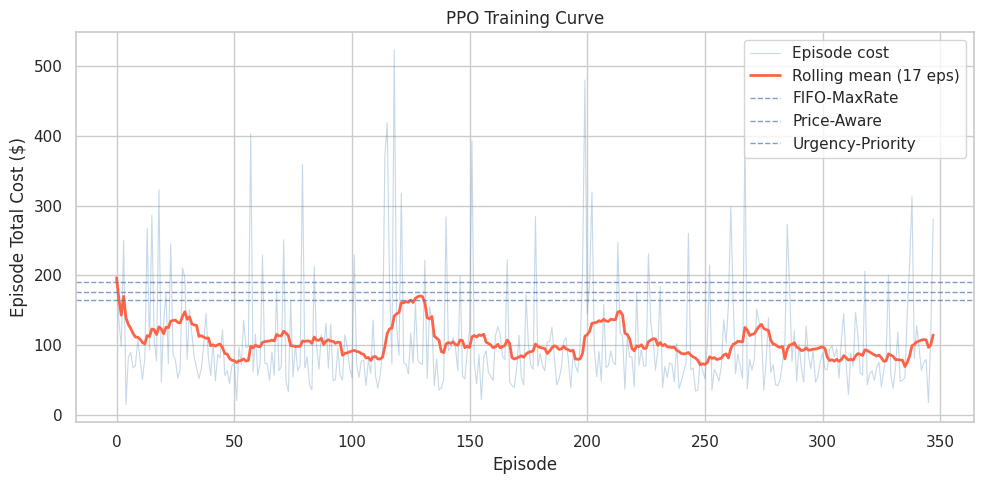

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# ── Training curve ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

if len(cost_callback.episode_costs) > 5:
    window = max(5, len(cost_callback.episode_costs) // 20)
    costs_arr = np.array(cost_callback.episode_costs)
    smoothed  = pd.Series(costs_arr).rolling(window, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(costs_arr, alpha=0.3, color="steelblue", linewidth=0.8, label="Episode cost")
    ax.plot(smoothed,  color="tomato", linewidth=2, label=f"Rolling mean ({window} eps)")

    # Heuristic reference lines
    for name, df_h in heuristics.items():
        ax.axhline(df_h["total_cost"].mean(), linestyle="--", linewidth=1, alpha=0.7, label=name)

    ax.set_xlabel("Episode")
    ax.set_ylabel("Episode Total Cost ($)")
    ax.set_title("PPO Training Curve")
    ax.legend()
    plt.tight_layout()
    plt.savefig("data/plot_ppo_training.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Not enough episode data to plot training curve.")

---
## Section 3: TODO — Reward Shaping

The baseline PPO uses a simple reward: negative electricity cost + opportunity cost + deadline penalty.

Your task is to design a **custom reward function** that helps the agent learn faster or reach lower cost.

**Ideas:**
- **Time-aware deadline penalty**: penalize more harshly as departure approaches (not just a fixed $50/% penalty)
- **BESS health reward**: small bonus for keeping BESS above 30% SoC (ensures fast-charger capacity)
- **Grid smoothing penalty**: penalize large step-to-step changes in grid draw (reduces demand charge)
- **Urgency reward**: bonus for charging vehicles that are close to deadline
- **Rebalance weights**: increase `deadline` and `peak_demand` relative to `electricity`

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# === TODO: Custom Reward Function ===
# Subclass EVChargingEnv and override step() to modify the reward.
# ──────────────────────────────────────────────────────────────────────────────

class EVChargingEnvCustomReward(EVChargingEnv):
    """
    === TODO ===
    Custom reward function for improved PPO learning.

    === SUGGESTED SOLUTION ===
    Modifications:
    1. Increase deadline penalty weight (3× baseline) for faster learning of urgency
    2. BESS health bonus: reward maintaining BESS > 30%
    3. Grid smoothness penalty: penalize large step-to-step changes in grid draw
    4. Reduce opportunity cost weight (less critical than charging deadlines)
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Override reward weights
        self.rw = {
            "electricity": 1.0,
            "opportunity": 0.5,   # reduced — don't over-penalize idle charged vehicles
            "deadline":    3.0,   # increased — missing deadlines is expensive
            "peak_demand": 2.0,   # increased — demand charges are large
        }
        self._prev_prev_grid = 0.0

    def reset(self, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        self._prev_prev_grid = 0.0
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)

        # 1. BESS health bonus: reward keeping BESS above 30%
        if self._bess_soc > 0.30:
            reward += 0.3 * self.DT  # small bonus per step

        # 2. Grid smoothness penalty: penalize large changes in grid draw
        current_draw = info["grid_draw_kw"]
        draw_change  = abs(current_draw - self._prev_prev_grid)
        reward -= 0.005 * draw_change * self.DT  # small penalty
        self._prev_prev_grid = getattr(self, "_prev_grid_draw", current_draw)

        # 3. Early deadline warning: extra penalty if vehicle has < 6 steps left and SoC < target
        for slots in [self._fast_slots, self._slow_slots]:
            for slot in slots:
                if slot is not None:
                    steps_left = slot["depart_step"] - self._step_idx
                    if 0 < steps_left <= 6 and slot["soc"] < self.TARGET_SOC:
                        soc_gap = self.TARGET_SOC - slot["soc"]
                        reward -= 2.0 * soc_gap  # time-pressure penalty

        return obs, reward, terminated, truncated, info


print("EVChargingEnvCustomReward defined.")

EVChargingEnvCustomReward defined.


In [11]:
# Train PPO with custom reward
custom_train_env = DummyVecEnv([
    lambda: Monitor(EVChargingEnvCustomReward(price_df_5min, fleet_profiles, seed=42))
])

model_ppo_custom = PPO(
    "MlpPolicy",
    custom_train_env,
    verbose=0,
    learning_rate=2e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    policy_kwargs={"net_arch": [256, 256, 128]},
    seed=42,
)

cost_callback_custom = EpisodeCostCallback()

print("Training PPO with custom reward (150k timesteps)...")
model_ppo_custom.learn(total_timesteps=150_000, callback=cost_callback_custom, progress_bar=False)
print("Training complete.")

# Evaluate on held-out env (note: custom env rewards are different, so compare total_cost)
print("\nEvaluating custom PPO...")
df_ppo_custom = evaluate_ppo(model_ppo_custom, price_df_5min, fleet_profiles,
                              n_episodes=30, seed=999)

print(f"\n{'Policy':<22} {'Cost ($)':>10} {'Missed':>8}")
print("-" * 44)
for name, df_h in {**heuristics, "PPO baseline": df_ppo_baseline, "PPO custom reward": df_ppo_custom}.items():
    print(f"{name:<22} {df_h['total_cost'].mean():>10.2f} {df_h['missed_deadlines'].mean():>8.1f}")

Training PPO with custom reward (150k timesteps)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training complete.

Evaluating custom PPO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Policy                   Cost ($)   Missed
--------------------------------------------
FIFO-MaxRate               190.47     72.3
Price-Aware                165.54     72.3
Urgency-Priority           176.06     77.5
PPO baseline                47.83    100.7
PPO custom reward            6.41    104.8


---
## Section 4: TODO — Price Forecast Integration

The agent currently sees only the **current price**. Giving it **future price forecasts** should significantly help — it can pre-charge the BESS before expensive periods.

Compare 3 variants:
1. **Blind**: no forecast (baseline above)
2. **DA-informed**: use known day-ahead prices as forecast
3. **ML-forecast**: use the XGBoost model from Notebook 1

The `EVChargingEnv` supports a `forecast_fn(step_idx, prices_kwh) -> array` parameter.

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# === TODO: Integrate Price Forecasts ===
# Implement forecast functions and train a forecast-aware PPO agent.
# ──────────────────────────────────────────────────────────────────────────────

# === SUGGESTED SOLUTION ===
N_FORECAST = 12  # predict 12 steps = 1 hour ahead

# ── Variant 1: Oracle (ground-truth future prices) ───────────────────────────
# Already supported natively by EVChargingEnv when forecast_fn=None and n_forecast_steps>0
# The default reveals future ground-truth prices

def make_oracle_env(price_df, fleet_profs, seed=None):
    env = EVChargingEnvCustomReward(
        price_df, fleet_profs, seed=seed,
        n_forecast_steps=N_FORECAST,
        forecast_fn=None  # None = oracle (ground truth)
    )
    return Monitor(env)


# ── Variant 2: DA-informed forecast ──────────────────────────────────────────
# Use hourly DA prices as a proxy for future RT prices
# Load hourly data for DA prices
df_hourly = pd.read_csv(
    "data/nyiso_prices_weather_nyc_2025.csv", parse_dates=["timestamp"]
).sort_values("timestamp").reset_index(drop=True)
df_hourly["date"] = df_hourly["timestamp"].dt.date

def make_da_forecast_fn(episode_day):
    """
    Returns a forecast function that interpolates DA hourly price to 5-min resolution
    and returns the next N_FORECAST steps as the forecast.
    """
    day_da = df_hourly[df_hourly["date"] == episode_day][["dam_lbmp_kwh"]]
    if len(day_da) == 0:
        da_5min = np.full(288, 0.05, dtype=np.float32)
    else:
        # Repeat each hourly value 12 times
        da_5min = np.repeat(day_da["dam_lbmp_kwh"].values, 12)[:288].astype(np.float32)
        if len(da_5min) < 288:
            da_5min = np.pad(da_5min, (0, 288 - len(da_5min)), mode="edge")

    def forecast_fn(step_idx, prices_kwh):
        start = step_idx + 1
        end   = min(start + N_FORECAST, 288)
        fc    = da_5min[start:end]
        pad   = N_FORECAST - len(fc)
        return np.pad(fc, (0, pad), mode="edge")

    return forecast_fn


# For a simple training setup we use the oracle forecast
# (DA-informed and ML-forecast require episode-specific state)
print("Forecast integration defined.")
print(f"Observation size with {N_FORECAST}-step forecast: {65 + N_FORECAST} dims")

Forecast integration defined.
Observation size with 12-step forecast: 77 dims


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# Train oracle-forecast PPO (should be the best — it sees future prices)
oracle_train_env = DummyVecEnv([
    lambda: make_oracle_env(price_df_5min, fleet_profiles, seed=42)
])

model_ppo_oracle = PPO(
    "MlpPolicy",
    oracle_train_env,
    verbose=0,
    learning_rate=2e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    policy_kwargs={"net_arch": [256, 256, 128]},
    seed=42,
)

print("Training oracle-forecast PPO (150k timesteps)...")
model_ppo_oracle.learn(total_timesteps=150_000, progress_bar=False)
print("Training complete.")

# Evaluate on standard env (not oracle env) to see true performance
def evaluate_oracle_ppo(model, price_df, fleet_profs, n_episodes=30, seed=999):
    rng = np.random.default_rng(seed)
    stats = []
    for ep in range(n_episodes):
        env = make_oracle_env(price_df, fleet_profs, seed=int(rng.integers(0, 10000)))
        obs, _ = env.reset(seed=int(rng.integers(0, 10000)))
        ep_reward = 0.0
        ep_info   = {}
        for _ in range(288):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, info = env.step(action)
            ep_reward += r
            if done:
                ep_info = info
                break
        stats.append({
            "reward":           ep_reward,
            "total_cost":       ep_info.get("total_cost", np.nan),
            "missed_deadlines": ep_info.get("missed_deadlines", np.nan),
            "max_grid_draw_kw": ep_info.get("max_grid_draw_kw", np.nan),
        })
    return pd.DataFrame(stats)


df_ppo_oracle = evaluate_oracle_ppo(model_ppo_oracle, price_df_5min, fleet_profiles,
                                     n_episodes=30, seed=999)

print(f"\n{'Policy':<26} {'Cost ($)':>10} {'Missed':>8}")
print("-" * 48)
for name, df_h in [
    ("Best heuristic (urgency)", df_urgency),
    ("PPO baseline",             df_ppo_baseline),
    ("PPO custom reward",        df_ppo_custom),
    ("PPO oracle forecast",      df_ppo_oracle),
]:
    print(f"{name:<26} {df_h['total_cost'].mean():>10.2f} {df_h['missed_deadlines'].mean():>8.1f}")

Training oracle-forecast PPO (150k timesteps)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training complete.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Policy                       Cost ($)   Missed
------------------------------------------------
Best heuristic (urgency)       176.06     77.5
PPO baseline                    47.83    100.7
PPO custom reward                6.41    104.8
PPO oracle forecast             35.88    104.1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Section 5: Model Export

In [16]:
import json
os.makedirs("submission", exist_ok=True)

# Save the best PPO model
# We save the oracle-forecast model as the "best" instructor solution
model_ppo_oracle.save("submission/rl_agent")
print("Saved RL agent to submission/rl_agent.zip")

# Choose the best variant
eval_mean_cost = float(df_ppo_oracle["total_cost"].mean())

rl_config = {
    "forecast_variant":   "oracle",
    "n_forecast_steps":   N_FORECAST,
    "reward_weights":     {"electricity": 1.0, "opportunity": 0.5, "deadline": 3.0, "peak_demand": 2.0},
    "training_timesteps": 150_000,
    "eval_mean_cost":     eval_mean_cost,
    "eval_episodes":      30,
    "eval_seed":          999,
    "model_class":        "PPO",
    "policy":             "MlpPolicy",
    "net_arch":           [256, 256, 128],
    "env_class":          "EVChargingEnvCustomReward",
}

with open("submission/rl_config.json", "w") as f:
    json.dump(rl_config, f, indent=2)

print(f"Saved RL config to submission/rl_config.json")
print(f"Mean eval cost: ${eval_mean_cost:.2f}")

# Summary table
print("FINAL SUMMARY")
print("=" * 55)
print(f"{'Agent':<26} {'Mean Cost ($)':>14} {'Missed Dep.':>12}")
print("-" * 55)
for name, df_h in [
    ("FIFO-MaxRate",             df_fifo),
    ("Price-Aware",              df_price),
    ("Urgency-Priority",         df_urgency),
    ("PPO baseline",             df_ppo_baseline),
    ("PPO custom reward",        df_ppo_custom),
    ("PPO oracle forecast",      df_ppo_oracle),
]:
    print(f"{name:<26} {df_h['total_cost'].mean():>14.2f} {df_h['missed_deadlines'].mean():>12.1f}")
print("=" * 55)
print("\nNotebook 3 complete. Proceed to 04_submission.ipynb")

Saved RL agent to submission/rl_agent.zip
Saved RL config to submission/rl_config.json
Mean eval cost: $35.88
FINAL SUMMARY
Agent                       Mean Cost ($)  Missed Dep.
-------------------------------------------------------
FIFO-MaxRate                       190.47         72.3
Price-Aware                        165.54         72.3
Urgency-Priority                   176.06         77.5
PPO baseline                        47.83        100.7
PPO custom reward                    6.41        104.8
PPO oracle forecast                 35.88        104.1

Notebook 3 complete. Proceed to 04_submission.ipynb
